In [2]:
# Step 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2 - Load the dataset
df = pd.read_csv('Healthcare No-Show data.csv')

# Step 3 - First look
print(df.head())
print(df.shape)
print(df.dtypes)

# Step 4 - Check missing values
print(df.isnull().sum())

# Step 5 - Basic statistics
print(df.describe())

      PatientId  AppointmentID Gender ScheduledDay AppointmentDay  Age  \
0  2.987250e+13        5642903      F   29-04-2016     29-04-2016   62   
1  5.589980e+14        5642503      M   29-04-2016     29-04-2016   56   
2  4.262960e+12        5642549      F   29-04-2016     29-04-2016   62   
3  8.679510e+11        5642828      F   29-04-2016     29-04-2016    8   
4  8.841190e+12        5642494      F   29-04-2016     29-04-2016   56   

       Neighbourhood  Scholarship  Hipertension  Diabetes  Alcoholism  \
0    JARDIM DA PENHA        False          True     False       False   
1    JARDIM DA PENHA        False         False     False       False   
2      MATA DA PRAIA        False         False     False       False   
3  PONTAL DE CAMBURI        False         False     False       False   
4    JARDIM DA PENHA        False          True      True       False   

   Handcap  SMS_received  Showed_up  Date.diff  
0    False         False       True          0  
1    False        

In [3]:
# Age rectification
print(df[df['Age'] > 100])
print(df[df['Age'] < 0])

          PatientId  AppointmentID Gender ScheduledDay AppointmentDay  Age  \
56030  9.762950e+14        5651757      F   03-05-2016     03-05-2016  102   
61803  3.196320e+13        5700278      F   16-05-2016     19-05-2016  115   
61806  3.196320e+13        5700279      F   16-05-2016     19-05-2016  115   
65876  3.196320e+13        5562812      F   08-04-2016     16-05-2016  115   
73825  3.196320e+13        5744037      F   30-05-2016     30-05-2016  115   
87422  2.342840e+11        5751563      F   31-05-2016     02-06-2016  102   
94560  7.482350e+14        5717451      F   19-05-2016     03-06-2016  115   

      Neighbourhood  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
56030     CONQUISTA        False         False     False       False    False   
61803    ANDORINHAS        False         False     False       False     True   
61806    ANDORINHAS        False         False     False       False     True   
65876    ANDORINHAS        False         False     

In [5]:
# Rectifing negative date
print(df[df['Date.diff'] < 0])

          PatientId  AppointmentID Gender ScheduledDay AppointmentDay  Age  \
26222  7.839270e+12        5679978      M   10-05-2016     09-05-2016   38   
53324  7.896290e+12        5715660      F   18-05-2016     17-05-2016   19   
62055  2.425230e+13        5664962      F   05-05-2016     04-05-2016   22   
69225  9.982320e+14        5686628      F   11-05-2016     05-05-2016   81   
70039  3.787480e+12        5655637      M   04-05-2016     03-05-2016    7   

        Neighbourhood  Scholarship  Hipertension  Diabetes  Alcoholism  \
26222    RESISTÃŠNCIA        False         False     False       False   
53324  SANTO ANTÃ”NIO        False         False     False       False   
62055    CONSOLAÃ‡ÃƒO        False         False     False       False   
69225  SANTO ANTÃ”NIO        False         False     False       False   
70039      TABUAZEIRO        False         False     False       False   

       Handcap  SMS_received  Showed_up  Date.diff  
26222     True         False     

In [6]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
print(df.dtypes)

PatientId                float64
AppointmentID              int64
Gender                    object
ScheduledDay      datetime64[ns]
AppointmentDay    datetime64[ns]
Age                        int64
Neighbourhood             object
Scholarship                 bool
Hipertension                bool
Diabetes                    bool
Alcoholism                  bool
Handcap                     bool
SMS_received                bool
Showed_up                   bool
Date.diff                  int64
dtype: object


C:\Users\HP\AppData\Local\Temp\ipykernel_13560\571134150.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
C:\Users\HP\AppData\Local\Temp\ipykernel_13560\571134150.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])


In [7]:
# specifing date format to scilence the warning

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], dayfirst=True)
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], dayfirst=True)
print(df.dtypes)

PatientId                float64
AppointmentID              int64
Gender                    object
ScheduledDay      datetime64[ns]
AppointmentDay    datetime64[ns]
Age                        int64
Neighbourhood             object
Scholarship                 bool
Hipertension                bool
Diabetes                    bool
Alcoholism                  bool
Handcap                     bool
SMS_received                bool
Showed_up                   bool
Date.diff                  int64
dtype: object


In [8]:
# Check impossible ages
print(df[df['Age'] > 100])
print(df[df['Age'] < 0])

# Check negative date differences
print(df[df['Date.diff'] < 0])

          PatientId  AppointmentID Gender ScheduledDay AppointmentDay  Age  \
56030  9.762950e+14        5651757      F   2016-05-03     2016-05-03  102   
61803  3.196320e+13        5700278      F   2016-05-16     2016-05-19  115   
61806  3.196320e+13        5700279      F   2016-05-16     2016-05-19  115   
65876  3.196320e+13        5562812      F   2016-04-08     2016-05-16  115   
73825  3.196320e+13        5744037      F   2016-05-30     2016-05-30  115   
87422  2.342840e+11        5751563      F   2016-05-31     2016-06-02  102   
94560  7.482350e+14        5717451      F   2016-05-19     2016-06-03  115   

      Neighbourhood  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
56030     CONQUISTA        False         False     False       False    False   
61803    ANDORINHAS        False         False     False       False     True   
61806    ANDORINHAS        False         False     False       False     True   
65876    ANDORINHAS        False         False     

In [9]:
# Drop impossible ages
df = df[df['Age'] <= 100]

# Drop negative date differences  
df = df[df['Date.diff'] >= 0]

# Verify the fix
print(df.shape)
print(df['Age'].max())
print(df['Date.diff'].min())

(106975, 15)
100
0


In [10]:
# STEP-1 checking target variable distribution

print(df['Showed_up'].value_counts())
print(df['Showed_up'].value_counts(normalize=True))

Showed_up
True     85303
False    21672
Name: count, dtype: int64
Showed_up
True     0.797411
False    0.202589
Name: proportion, dtype: float64


In [13]:
#Target Variable Distribution The dataset is imbalanced — 80% of patients showed up, 20% did not. 
#This means accuracy alone is not a reliable metric. We will use precision, recall and F1-score to evaluate models instead.

In [14]:
# No-show rate by SMS
print(df.groupby('SMS_received')['Showed_up'].value_counts(normalize=True))

# No-show rate by gender
print(df.groupby('Gender')['Showed_up'].value_counts(normalize=True))

SMS_received  Showed_up
False         True         0.832797
              False        0.167203
True          True         0.723340
              False        0.276660
Name: proportion, dtype: float64
Gender  Showed_up
F       True         0.796471
        False        0.203529
M       True         0.799197
        False        0.200803
Name: proportion, dtype: float64


In [15]:
## Key EDA Findings

### SMS Reminders
# Patients who received SMS reminders showed a higher no-show rate (27%) 
# compared to those who didn't (17%). This is counterintuitive but likely 
# reflects selection bias — SMS reminders were sent to higher-risk patients.
# Correlation does not imply causation here.

### Gender
# No meaningful difference in no-show rates between male and female patients.
# Gender is unlikely to be a useful predictor in our model.

In [16]:
# No-show rate by age group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,18,35,60,100], 
                labels=['Child','Young Adult','Adult','Senior'])
print(df.groupby('AgeGroup')['Showed_up'].value_counts(normalize=True))

AgeGroup     Showed_up
Child        True         0.774658
             False        0.225342
Young Adult  True         0.761715
             False        0.238285
Adult        True         0.809004
             False        0.190996
Senior       True         0.848031
             False        0.151969
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_13560\1698392141.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Showed_up'].value_counts(normalize=True))


In [17]:
### Age Groups
# Clear pattern exists across age groups:
# - Seniors (60+): lowest no-show rate at 15%
# - Young Adults (18-35): highest no-show rate at 24%
# - Age is likely a useful predictor for our model unlike gender.

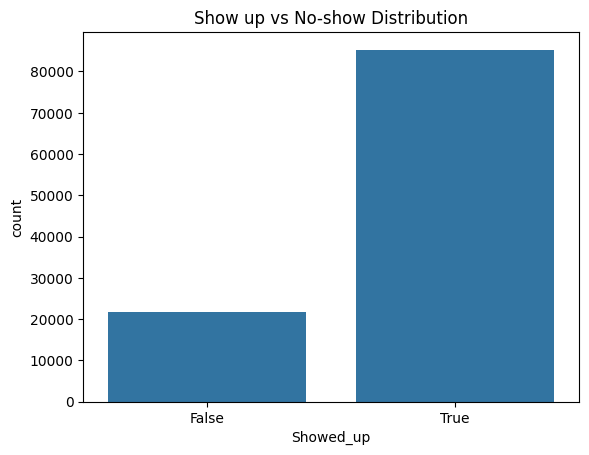

In [18]:
# No-show count plot
sns.countplot(data=df, x='Showed_up')
plt.title('Show up vs No-show Distribution')
plt.savefig('target_distribution.png')
plt.show()

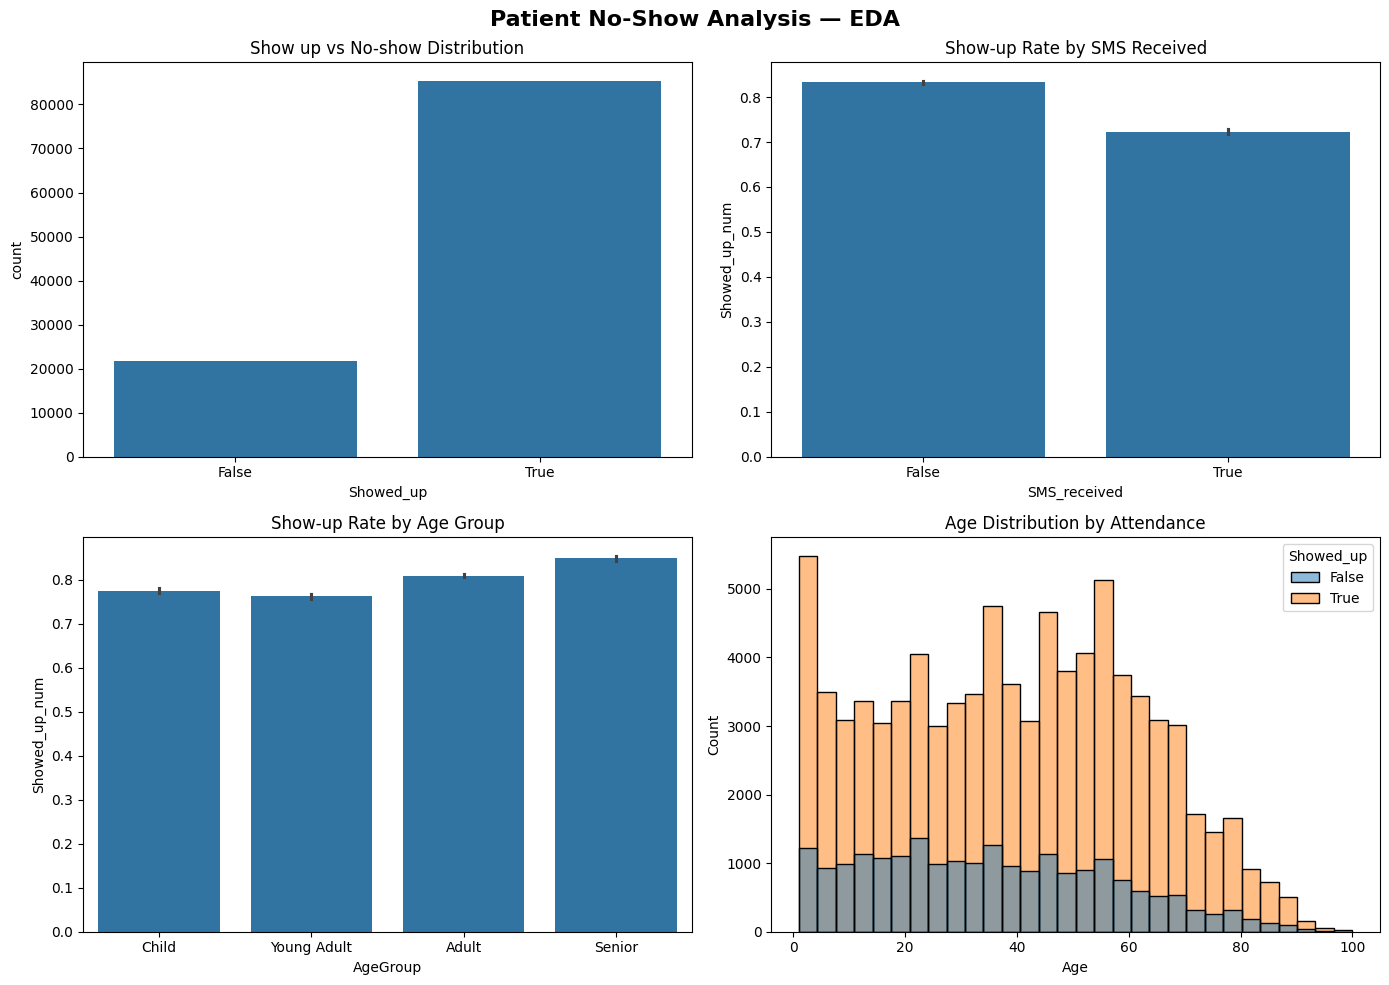

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Target distribution
sns.countplot(data=df, x='Showed_up', ax=axes[0,0])
axes[0,0].set_title('Show up vs No-show Distribution')

# Chart 2 - SMS vs No-show
sns.barplot(data=df, x='SMS_received', y='Showed_up_num', ax=axes[0,1])
axes[0,1].set_title('Show-up Rate by SMS Received')

# Chart 3 - Age group vs No-show
sns.barplot(data=df, x='AgeGroup', y='Showed_up_num', ax=axes[1,0])
axes[1,0].set_title('Show-up Rate by Age Group')

# Chart 4 - Age distribution
sns.histplot(data=df, x='Age', hue='Showed_up', bins=30, ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Attendance')

fig.suptitle('Patient No-Show Analysis — EDA', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visualisations.png', bbox_inches='tight', dpi=150)
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode Gender
df['Gender_encoded'] = LabelEncoder().fit_transform(df['Gender'])

# Select features
features = ['Age', 'Gender_encoded', 'Scholarship', 'Hipertension', 
            'Diabetes', 'Alcoholism', 'SMS_received', 'Date.diff']

X = df[features]
y = df['Showed_up_num']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

ModuleNotFoundError: No module named 'sklearn'

In [26]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 3.7 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 7.5 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 8.8 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 8.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -- ------------------------------------- 2.1/36.5 MB 14.7 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/36.5 MB 14.4 MB/s eta 0:00:03
   ------- -------------------------------- 6.6/36.5 MB 11.2 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/36.5 MB 11.5 MB/s eta 0:00:03
   ------------- -------------------------- 12.1/36.5 MB 12.0 MB/s eta 0:00:03
   --------------- ------------------------ 14.4/36.5 MB 11.9 MB/s eta 0:00:02
   --------

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode Gender
df['Gender_encoded'] = LabelEncoder().fit_transform(df['Gender'])

# Select features
features = ['Age', 'Gender_encoded', 'Scholarship', 'Hipertension', 
            'Diabetes', 'Alcoholism', 'SMS_received', 'Date.diff']

X = df[features]
y = df['Showed_up_num']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (85580, 8)
Test set: (21395, 8)


=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.36      0.01      0.03      4278
           1       0.80      0.99      0.89     17117

    accuracy                           0.80     21395
   macro avg       0.58      0.50      0.46     21395
weighted avg       0.71      0.80      0.72     21395



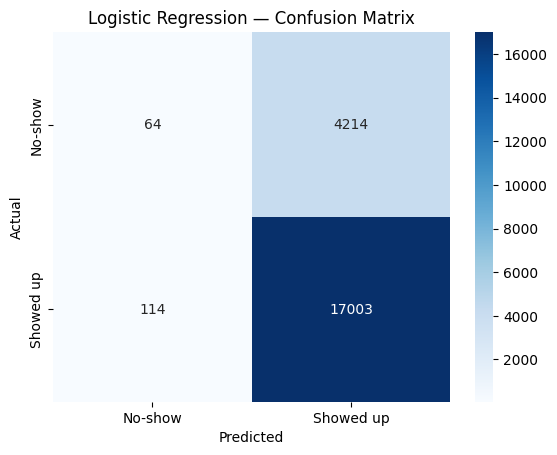

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Build model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No-show', 'Showed up'],
            yticklabels=['No-show', 'Showed up'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.31      0.41      0.35      4278
           1       0.84      0.77      0.80     17117

    accuracy                           0.70     21395
   macro avg       0.57      0.59      0.58     21395
weighted avg       0.73      0.70      0.71     21395



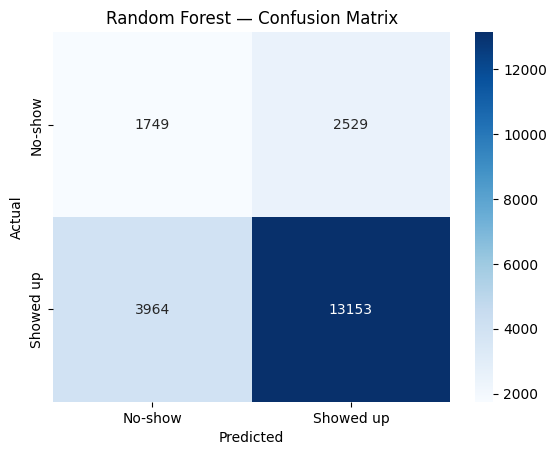

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',
    random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No-show', 'Showed up'],
            yticklabels=['No-show', 'Showed up'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

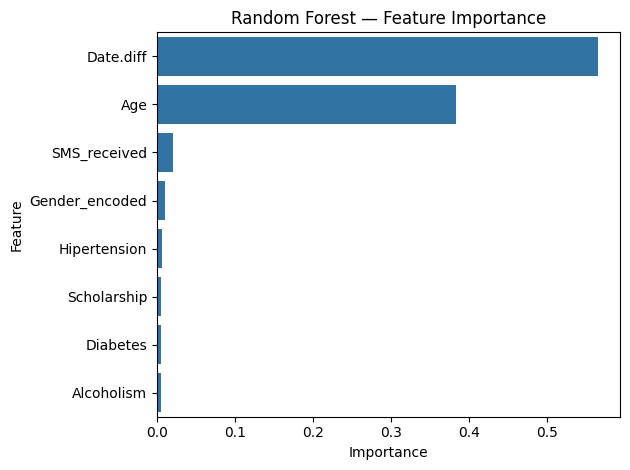

          Feature  Importance
7       Date.diff    0.565501
0             Age    0.382994
6    SMS_received    0.020613
1  Gender_encoded    0.010027
3    Hipertension    0.006378
2     Scholarship    0.005393
4        Diabetes    0.004578
5      Alcoholism    0.004516


In [30]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(feature_importance)